# Задание 1. Ridge-регрессия

#### Шаг 1. Загрузка датасета и вывод на экран

In [1]:
import pandas as pd

# Задаем путь к файлу
file_path = r"C:\Users\koval\OneDrive\Desktop\ML\практика\apartment_dataset.csv"

# Загружаем датасет
df = pd.read_csv(file_path)

# Выводим общую информацию о таблице
print(f"Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов\n")

# Выводим первые 5 строк
print("Первые 5 строк таблицы:")
print(df.head())

# Дополнительно можно посмотреть типы данных и наличие пропусков:
# print(df.info())

Размер датасета: 200 строк, 6 столбцов

Первые 5 строк таблицы:
   apartment id  rooms  total area  floor  complex rating  price
0             1      2        60.8      9             4.2  11.54
1             2      4       102.5     17             4.6  20.22
2             3      3        75.7     17             4.9  15.74
3             4      2        66.0     20             4.7  14.10
4             5      1        39.7     16             3.6   6.71


#### Шаг2. Разделение выборки на тренировочную, валидационную и тестовую:
* в тренировочной: 100 первых квартир;
* в валидационной: 50 следующих квартир; 
* в тестовой: 50 последних квартир.
* в каждой выборке матрица X - это столбцы rooms, total area, floor, complex rating, а y - столбец price. 

Названия: X_train, y_train, X_val, y_val, X_test, y_test. 

In [4]:
# Список столбцов-признаков (X) и целевой переменной (y)
feature_cols = ['rooms', 'total area', 'floor', 'complex rating']
target_col = 'price'

# 1. Тренировочная выборка: первые 100 квартир (индексы от 0 до 99)
train_df = df.iloc[:100]
X_train = train_df[feature_cols]
y_train = train_df[target_col]

# 2. Валидационная выборка: следующие 50 квартир (индексы от 100 до 149)
val_df = df.iloc[100:150]
X_val = val_df[feature_cols]
y_val = val_df[target_col]

# 3. Тестовая выборка: последние 50 квартир (индексы от 150 до 199)
test_df = df.iloc[150:200]
X_test = test_df[feature_cols]
y_test = test_df[target_col]

# Проверяем размерности получившихся выборок
print(f"Обучающая выборка (X_train, y_train): {X_train.shape}, {y_train.shape}")
print(f"Валидационная выборка (X_val, y_val): {X_val.shape}, {y_val.shape}")
print(f"Тестовая выборка (X_test, y_test):     {X_test.shape}, {y_test.shape}")

Обучающая выборка (X_train, y_train): (100, 4), (100,)
Валидационная выборка (X_val, y_val): (50, 4), (50,)
Тестовая выборка (X_test, y_test):     (50, 4), (50,)


#### Шаг 3. Установка sklearn чтобы обучать модель Ridge-регрессии

In [6]:
!pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.3 MB 8.2 MB/s eta 0:00:01
   ---------------------- ----------------- 4.7/8.3 MB 17.8 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 17.7 MB/s  0:00:00
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

   ------------- -------------------------- 1/3 [narwhals]
   ------------- -------------------------- 1/3 [narwhals]
   ------------- -------------------------- 1/3 [narwhals]
   ------------- -------------------------- 1/3 [narwhals]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


#### Шаг 4. Обучение модели линейной регрессии на тренировочной выборке с помощью Ridge и sparse_cg с ошибкой, которая вычисляется по формуле SSE.

In [ ]:
import numpy as np
from sklearn.linear_model import Ridge

# 1. Создаем модель линейной регрессии через Ridge с солвером sparse_cg
# alpha=0.0 отключает регуляризацию, оставляя чистую линейную регрессию
model = Ridge(alpha=0.0, solver='sparse_cg')

# 2. Обучаем модель на тренировочной выборке
model.fit(X_train, y_train)

# 3. Получаем предсказания модели на обучающих данных: \hat{y}
y_train_pred = model.predict(X_train)

# 4. Вычисляем ошибку по формуле SSE: L(w) = sum((y - \hat{y})^2)
sse_train = np.sum((y_train - y_train_pred) ** 2)

# Выводим результаты
print("Обучение завершено успешно!")
print(f"Свободный член (w0 / intercept): {model.intercept_:.4f}")
print("Веса признаков (w1, w2, w3, w4):")
for feature, weight in zip(feature_cols, model.coef_):
    print(f"  {feature}: {weight:.4f}")

Обучение завершено успешно!
Свободный член (w0 / intercept): -7.6675
Веса признаков (w1, w2, w3, w4):
  rooms: 0.3678
  total area: 0.1477
  floor: 0.0418
  complex rating: 2.1303

Ошибка SSE на тренировочной выборке: 14.3979


#### Шаг 5. Вывод на экран графиков ошибок (SSE, MSE, RMSE) в зависимости от итераций для train и val выборок.

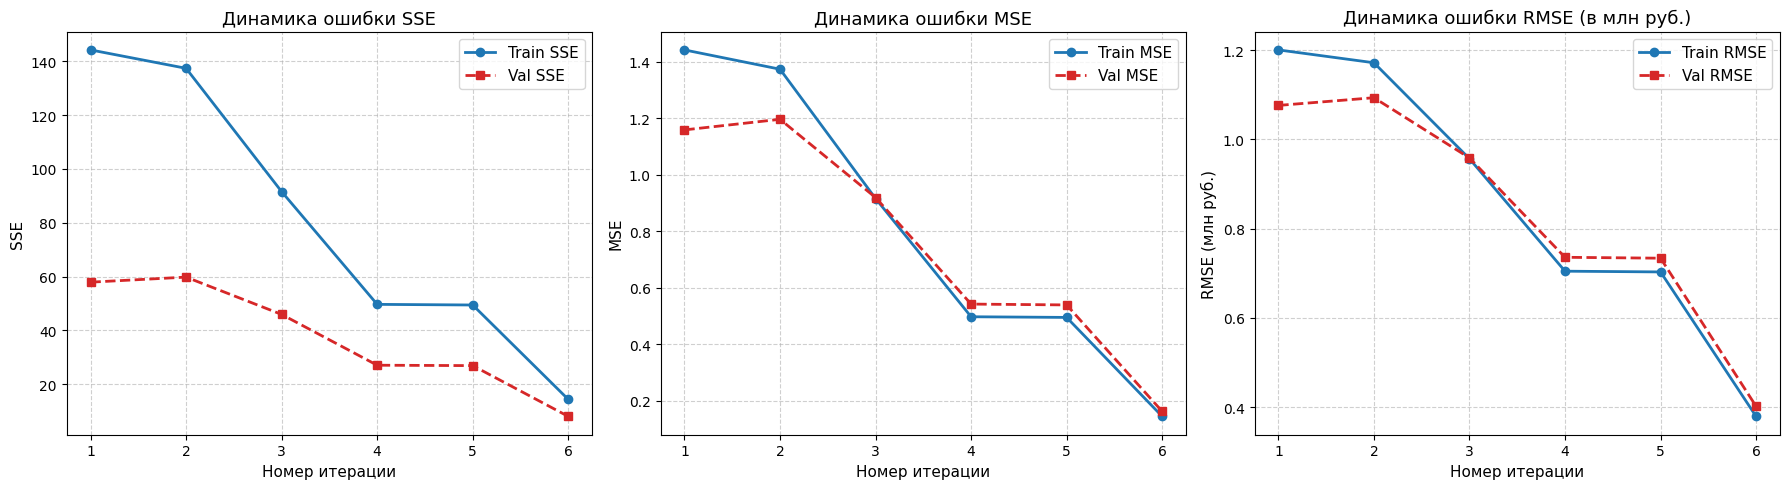

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Готовим матрицы признаков с единичным столбцом для w0
m_train = len(X_train)
m_val = len(X_val)

X_mat = np.column_stack([np.ones(m_train), X_train.values])
y_vec = y_train.values

X_val_mat = np.column_stack([np.ones(m_val), X_val.values])
y_val_vec = y_val.values

# 2. Формируем СЛАУ по обучающим данным: A * w = b
A = X_mat.T @ X_mat
b = X_mat.T @ y_vec

# 3. Инициализация параметров
w = np.zeros(X_mat.shape[1])
r = b - A @ w
p = r.copy()

# Списки для сохранения истории метрик (train и val)
train_sse_history, val_sse_history = [], []
train_mse_history, val_mse_history = [], []
train_rmse_history, val_rmse_history = [], []

max_iter = 20
epsilon = 1e-6

# 4. Итерационный процесс сопряженных градиентов
for it in range(1, max_iter + 1):
    Ap = A @ p
    alpha = (r.T @ r) / (p.T @ Ap)
    w = w + alpha * p
    r_next = r - alpha * Ap
    
    # Метрики на тренировочной выборке
    y_pred = X_mat @ w
    sse_tr = np.sum((y_vec - y_pred) ** 2)
    mse_tr = sse_tr / m_train
    rmse_tr = np.sqrt(mse_tr)
    
    train_sse_history.append(sse_tr)
    train_mse_history.append(mse_tr)
    train_rmse_history.append(rmse_tr)
    
    # Метрики на валидационной выборке (с текущими весами w)
    y_val_pred = X_val_mat @ w
    sse_v = np.sum((y_val_vec - y_val_pred) ** 2)
    mse_v = sse_v / m_val
    rmse_v = np.sqrt(mse_v)
    
    val_sse_history.append(sse_v)
    val_mse_history.append(mse_v)
    val_rmse_history.append(rmse_v)
    
    # Критерий останова по норме невязки на обучении
    if np.linalg.norm(r_next) < epsilon:
        break
        
    beta = (r_next.T @ r_next) / (r.T @ r)
    p = r_next + beta * p
    r = r_next

iterations = list(range(1, len(train_sse_history) + 1))

# 5. Построение трех графиков с двумя линиями (Train и Val)
plt.figure(figsize=(18, 5))

# График 1: SSE
plt.subplot(1, 3, 1)
plt.plot(iterations, train_sse_history, marker='o', color='tab:blue', linewidth=2, label='Train SSE')
plt.plot(iterations, val_sse_history, marker='s', color='tab:red', linestyle='--', linewidth=2, label='Val SSE')
plt.title('Динамика ошибки SSE', fontsize=13)
plt.xlabel('Номер итерации', fontsize=11)
plt.ylabel('SSE', fontsize=11)
plt.xticks(iterations)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)

# График 2: MSE
plt.subplot(1, 3, 2)
plt.plot(iterations, train_mse_history, marker='o', color='tab:blue', linewidth=2, label='Train MSE')
plt.plot(iterations, val_mse_history, marker='s', color='tab:red', linestyle='--', linewidth=2, label='Val MSE')
plt.title('Динамика ошибки MSE', fontsize=13)
plt.xlabel('Номер итерации', fontsize=11)
plt.ylabel('MSE', fontsize=11)
plt.xticks(iterations)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)

# График 3: RMSE
plt.subplot(1, 3, 3)
plt.plot(iterations, train_rmse_history, marker='o', color='tab:blue', linewidth=2, label='Train RMSE')
plt.plot(iterations, val_rmse_history, marker='s', color='tab:red', linestyle='--', linewidth=2, label='Val RMSE')
plt.title('Динамика ошибки RMSE (в млн руб.)', fontsize=13)
plt.xlabel('Номер итерации', fontsize=11)
plt.ylabel('RMSE (млн руб.)', fontsize=11)
plt.xticks(iterations)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

#### Шаг 6. Применение модели на тестовой выборке, чтобы предсказать цены квартир.

In [11]:
import pandas as pd

# 1. Получаем предсказания модели на тестовой выборке
# Если вы используете обученную модель Ridge:
y_test_pred = model.predict(X_test)

# Если вы используете найденный вектор весов w из собственного цикла CG:
# X_test_mat = np.column_stack([np.ones(len(X_test)), X_test.values])
# y_test_pred = X_test_mat @ w

# 2. Формируем итоговую таблицу результатов
# test_df содержит исходные строки 150:200 из общего датафрейма df
results_df = pd.DataFrame()

# Столбец apartment id
results_df['apartment id'] = test_df['apartment id']

# Столбцы признаков X_test
for col in feature_cols:
    results_df[col] = X_test[col]

# Столбец фактических цен (y_test)
results_df['actual_price'] = y_test

# Столбец предсказанных моделью цен
results_df['predicted_price'] = np.round(y_test_pred, 2)

# Дополнительно: абсолютная разница в млн руб.
results_df['absolute_error'] = np.round(np.abs(results_df['actual_price'] - results_df['predicted_price']), 2)

# 3. Настройка вывода pandas, чтобы отобразить все 50 строк без обрезки
pd.set_option('display.max_rows', 60)
pd.set_option('display.max_columns', 10)
pd.set_option('display.width', 1000)

# Выводим таблицу
print("Сравнение фактических и предсказанных цен на тестовой выборке (50 квартир):")
print(results_df)

Сравнение фактических и предсказанных цен на тестовой выборке (50 квартир):
     apartment id  rooms  total area  floor  complex rating  actual_price  predicted_price  absolute_error
150           151      4       115.1     17             4.4         21.54            20.89            0.65
151           152      1        43.7      9             4.9          9.73             9.97            0.24
152           153      1        40.5      1             4.2          7.74             7.67            0.07
153           154      2        51.3     21             4.2         10.15            10.47            0.32
154           155      4       102.1     20             3.7         17.27            17.60            0.33
155           156      1        40.3     13             4.6          8.23             9.00            0.77
156           157      2        48.5     16             3.5          8.52             8.36            0.16
157           158      3        85.5     13             3.8         